# Класифікація зображень і базова згорткова мережа
## Бізнес-контекст
Компанія VisionScan AI розробляє систему автоматичного розпізнавання рукописних цифр для обробки банківських документів.
Ваше завдання — створити першу версію моделі, яка класифікує цифри 0-9 за зображеннями, використовуючи PyTorch.

*pip install torchvision*

In [1]:
import torch, torchvision

## Завдання 1
Підготуйте дані.
- Використовуйте датасет MNIST із torchvision.datasets.
- Завантажте навчальну і тестову вибірки.
- Перетворіть зображення в тензори та нормалізуйте їх.
- Створіть DataLoader із батчем розміром 64.

In [2]:
# Перетворіть зображення в тензори та нормалізуйте їх.
# Зображення у датасетах під час завантаження приймають параметри перетворень,
# тому задаємо їх ДО завантаження
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),                # нормалізація - середне та відхилення по кожному 
    torchvision.transforms.Normalize((0.5,), (0.5,))  # кольору, для ЧБ зображень один канал кольору
])

# Завантажте навчальну і тестову вибірки.
train_data = torchvision.datasets.MNIST(  #  датасет - MNIST
    root="data",                          #  корень завантаження (! не забути додати до .gitignore)
    train=True,                           #  навчальна вибірка
    download=True,                        #  із завантаженням
    transform=transform                   #  раніше підготовлене перетворення
)
test_data = torchvision.datasets.MNIST(   #  датасет - MNIST
    root="data",                          #  корень завантаження (! не забути додати до .gitignore)
    train=False,                          #  тестова вибірка
    download=True,                        #  із завантаженням
    transform=transform                   #  раніше підготовлене перетворення
)

In [3]:
# Створіть DataLoader із батчем розміром 64.
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

In [4]:
# візуалізуємо завантажені дані
import matplotlib.pyplot as plt

In [5]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(len(labels), labels[:5])
images[0].shape  # torch.Size([1, 28, 28]) - монохром (1 колір) розміром 28х28

64 tensor([1, 2, 2, 9, 3])


torch.Size([1, 28, 28])

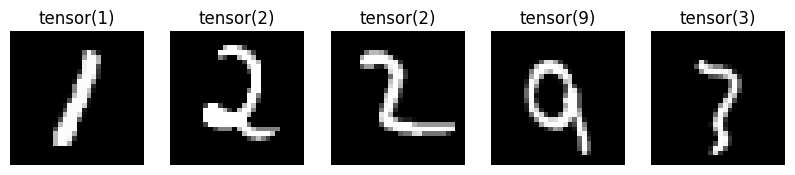

In [6]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(labels[i])
    plt.axis('off')
plt.show()

## Завдання 2
Побудуйте просту згорткову нейронну мережу.
- Використовуйте шари:
    - Conv2d(1, 16, kernel_size=3);
    - ReLU();
    - MaxPool2d(2);
    - Flatten();
    - Linear(16 * 13 * 13, 10).
- Функція втрат — CrossEntropyLoss, оптимізатор — Adam(lr=0.001).
- Навчіть модель 10 епох.

Згорткова (конволюційна) мережа: 

In [7]:
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = torch.nn.Conv2d(1, 16, kernel_size=3)
        self.activation = torch.nn.ReLU()
        self.pool = torch.nn.MaxPool2d(2)
        self.flatten = torch.nn.Flatten()
        self.fc = torch.nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.activation(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# Функція втрат — CrossEntropyLoss, оптимізатор — Adam(lr=0.001).
cnn = SimpleCNN()

# Перевіряємо чи є прискорювачі
if (current_device := torch.accelerator.current_accelerator(check_available=True)) is not None:
    model.to(current_device)
    print(current_device)
else :
    print("No accelerators")
    
loss_f = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

# збереження моделі - див. далі, тут перевіряємо чи є збережі дані
try :
    state_dict = torch.load("mnist_cnn.pth", weights_only=True)
    cnn.load_state_dict(state_dict)
    print("State loaded")
except :
    print("No state loaded, new model created")

No accelerators
State loaded


In [8]:
# Навчіть модель 10 епох.
epochs = 10
losses = []
for epoch in range(epochs):
    loss_acc = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = loss_f(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_acc += loss.item()
    losses.append(loss_acc)
    print(epoch + 1, loss_acc)


1 11.57905915316951
2 9.363914302735793
3 8.2296385930822
4 7.854157263744128
5 6.892321532679489
6 6.949099495830524
7 6.368263446565834
8 5.247740077931667
9 5.777300355312036
10 5.300350917086689


# Завдання 3
Відстежуйте та візуалізуйте процес навчання.
- Виведіть втрати за епохами.
- Побудуйте графік залежності loss від епох.
- Збережіть модель у файл mnist_cnn.pth.

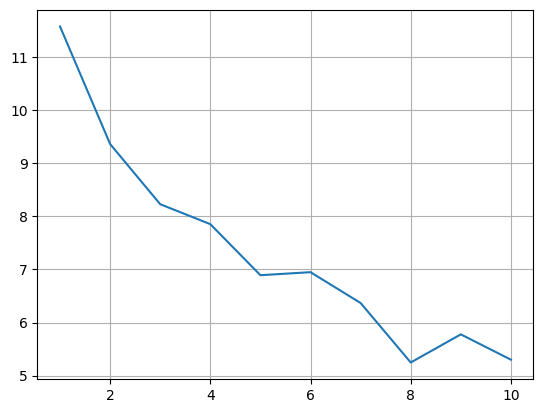

In [9]:
_, ax = plt.subplots()
ax.plot(range(1,epochs+1), losses)
ax.grid()
plt.show()

In [10]:
# Збережіть модель у файл mnist_cnn.pth.
# Складна модель довго навчається і є сенс зберігати її стан з можливістю подальшого відновлення
torch.save(cnn.state_dict(), "mnist_cnn.pth")

## Завдання 4
Перевірте точність моделі на тестовій вибірці та оформіть результати:

|Метрика|Значення|
|-|-|
|Accuracy|...|
|Loss|...|


In [11]:
correct = 0
total = 0
mis = []
with torch.no_grad():
    for images, labels in test_loader:
        predictions = cnn(images)   # 10 елементів, з яких треба вибрати максимальний
        _, predicted = torch.max(predictions, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # зберігаємо неправильно передбачені випадки (для візуалізації)
        for i in range(len(labels)):
            if predicted[i] != labels[i] :
                mis.append({
                    'label': labels[i],
                    'predicted': predicted[i],
                    'img': images[i]
                })
print(total, correct, correct / total * 100, (total-correct) / total * 100)

10000 9824 98.24000000000001 1.76


In [12]:
from IPython.display import Markdown as md

In [15]:
md(f"""|Метрика|10 епох|20 епох|30 епох|
|-|-|-|-|
|Accuracy|{97.95}|{98.28}|{98.24}|
|Loss|{2.05}|{1.72}|{1.76}|""")

|Метрика|10 епох|20 епох|30 епох|
|-|-|-|-|
|Accuracy|97.95|98.28|98.24|
|Loss|2.05|1.72|1.76|

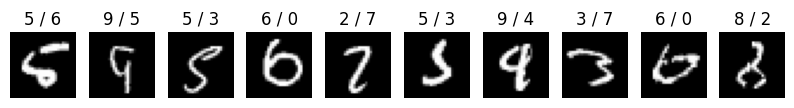

In [16]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(mis[i]['img'].squeeze(), cmap='gray')
    plt.title(f"{mis[i]['label']} / {mis[i]['predicted']}")
    plt.axis('off')
plt.show()

За ознаками ранньої зупинки слід зупинитись на 25 епосі